# Network Traffic Anomaly Detection System

## Project Objective

The objective of this project is to build a **Machine Learning-based Network Traffic Anomaly Detection System** capable of identifying suspicious or malicious network activities from normal traffic patterns.

This project uses network traffic features such as:

- Packet Size
- Inter Arrival Time
- Source/Destination Ports
- Packet Count
- Spectral Entropy
- Frequency Band Energy
- TCP Flags
- Protocol Type

The goal is to classify network traffic into:

- **Normal Traffic (0)**
- **Anomalous Traffic (1)**

### Machine Learning Models Used

1. Random Forest Classifier
2. XGBoost Classifier
3. Isolation Forest (Unsupervised Anomaly Detection)

This project also includes:

- Exploratory Data Analysis (EDA)
- Feature Engineering
- Feature Scaling
- Model Evaluation
- Feature Importance Analysis
- Model Saving
- Sample Prediction

In [2]:
# ================================
# Import Required Libraries
# ================================

# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler

# Models
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import IsolationForest


# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Model Saving
import joblib

# Plot settings
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8,5)

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [3]:
# ================================
# Load Dataset
# ================================

df = pd.read_csv("network_traffic.csv")

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [4]:
# Display first 10 rows

df.head(10)

,packet_size,inter_arrival_time,src_port,dst_port,packet_count_5s,mean_packet_size,spectral_entropy,frequency_band_energy,label,protocol_type_TCP,protocol_type_UDP,src_ip_192.168.1.2,src_ip_192.168.1.3,dst_ip_192.168.1.5,dst_ip_192.168.1.6,tcp_flags_FIN,tcp_flags_SYN,tcp_flags_SYN-ACK
0,0.405154,0.620362,62569,443,0.857143,0.0,0.834066,0.534891,0.0,False,True,True,False,False,False,False,False,False
1,0.527559,0.741288,59382,443,0.785714,0.0,0.147196,0.990757,0.0,False,True,False,False,False,True,False,True,False
2,0.226199,0.485116,65484,80,0.285714,0.0,0.855192,0.031781,0.0,False,True,False,False,True,False,False,False,False
3,0.573372,0.450965,51707,53,0.142857,0.0,0.153220,0.169958,0.0,False,False,False,True,False,False,False,False,False
4,0.651396,0.888740,26915,53,0.714286,0.0,0.923916,0.552053,0.0,True,False,False,True,False,False,False,True,False
5,0.568361,0.207250,2619,53,0.928571,0.0,0.113375,0.582346,0.0,True,False,True,False,False,False,False,False,False
6,0.571940,0.363908,14582,53,0.714286,0.0,0.874457,0.760548,0.0,False,False,True,False,False,False,False,True,False
7,0.173228,0.075335,5724,443,0.428571,0.0,0.541747,0.175055,0.0,False,False,True,False,True,False,False,False,True
8,0.967788,0.493461,28474,443,0.071429,0.0,0.330655,0.023906,0.0,False,False,False,False,False,False,True,False,False
9,0.364352,0.434362,22620,443,0.571429,0.0,0.056789,0.172246,0.0,False,True,False,True,False,True,False,False,False


In [5]:

# Dataset Shape


print("Number of Rows :", df.shape[0])
print("Number of Columns :", df.shape[1])

Number of Rows : 1000
Number of Columns : 18


In [6]:

# Dataset Information


df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   packet_size            1000 non-null   float64
 1   inter_arrival_time     1000 non-null   float64
 2   src_port               1000 non-null   int64  
 3   dst_port               1000 non-null   int64  
 4   packet_count_5s        1000 non-null   float64
 5   mean_packet_size       1000 non-null   float64
 6   spectral_entropy       1000 non-null   float64
 7   frequency_band_energy  1000 non-null   float64
 8   label                  1000 non-null   float64
 9   protocol_type_TCP      1000 non-null   bool   
 10  protocol_type_UDP      1000 non-null   bool   
 11  src_ip_192.168.1.2     1000 non-null   bool   
 12  src_ip_192.168.1.3     1000 non-null   bool   
 13  dst_ip_192.168.1.5     1000 non-null   bool   
 14  dst_ip_192.168.1.6     1000 non-null   bool   
 15  tcp_f

In [7]:

# Statistical Summary


df.describe().T

,count,mean,std,min,25%,50%,75%,max
packet_size,1000.0,0.502446,0.289606,0.0,0.256263,0.499642,0.741410,1.0
inter_arrival_time,1000.0,0.512259,0.281130,0.0,0.275909,0.515971,0.746523,1.0
src_port,1000.0,32024.617000,18520.890349,1038.0,16245.250000,31883.000000,47746.250000,65484.0
dst_port,1000.0,199.769000,180.078488,53.0,53.000000,80.000000,443.000000,443.0
packet_count_5s,1000.0,0.506857,0.303271,0.0,0.267857,0.500000,0.785714,1.0
mean_packet_size,1000.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0
spectral_entropy,1000.0,0.495222,0.292927,0.0,0.236912,0.504290,0.761556,1.0
frequency_band_energy,1000.0,0.485651,0.295953,0.0,0.228039,0.467905,0.750876,1.0
label,1000.0,0.100000,0.300150,0.0,0.000000,0.000000,0.000000,1.0


In [8]:

# Identify Column Types

numerical_cols = df.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

categorical_cols = df.select_dtypes(
    include=['bool', 'object']
).columns.tolist()

# Remove target column
numerical_cols.remove('label')

print("Numerical Columns:\n")
print(numerical_cols)

print("\nCategorical Columns:\n")
print(categorical_cols)

Numerical Columns:

['packet_size', 'inter_arrival_time', 'src_port', 'dst_port', 'packet_count_5s', 'mean_packet_size', 'spectral_entropy', 'frequency_band_energy']

Categorical Columns:

['protocol_type_TCP', 'protocol_type_UDP', 'src_ip_192.168.1.2', 'src_ip_192.168.1.3', 'dst_ip_192.168.1.5', 'dst_ip_192.168.1.6', 'tcp_flags_FIN', 'tcp_flags_SYN', 'tcp_flags_SYN-ACK']


In [9]:

# Missing Values Check


missing_values = df.isnull().sum()

missing_df = pd.DataFrame({
    'Column': missing_values.index,
    'Missing Values': missing_values.values
})

missing_df[missing_df['Missing Values'] > 0]

,Column,Missing Values


In [10]:

# Duplicate Records


duplicate_count = df.duplicated().sum()

print("Duplicate Records :", duplicate_count)

Duplicate Records : 0


In [11]:

# Unique Values in Each Column


for col in df.columns:
    print(f"{col} : {df[col].nunique()}")

packet_size : 698
inter_arrival_time : 1000
src_port : 995
dst_port : 3
packet_count_5s : 15
mean_packet_size : 1
spectral_entropy : 1000
frequency_band_energy : 1000
label : 2
protocol_type_TCP : 2
protocol_type_UDP : 2
src_ip_192.168.1.2 : 2
src_ip_192.168.1.3 : 2
dst_ip_192.168.1.5 : 2
dst_ip_192.168.1.6 : 2
tcp_flags_FIN : 2
tcp_flags_SYN : 2
tcp_flags_SYN-ACK : 2


In [12]:

# Class Distribution


df['label'].value_counts()

label
0.0    900
1.0    100
Name: count, dtype: int64

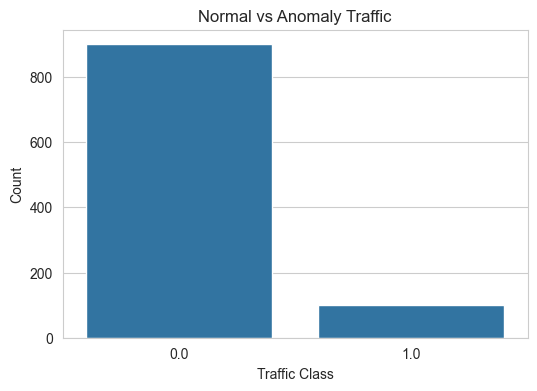

In [13]:

# Class Imbalance Visualization


plt.figure(figsize=(6,4))

sns.countplot(x='label', data=df)

plt.title("Normal vs Anomaly Traffic")
plt.xlabel("Traffic Class")
plt.ylabel("Count")

plt.show()

In [14]:

# Class Percentage


class_percentage = (
    df['label']
    .value_counts(normalize=True)
    * 100
)

print(class_percentage)

label
0.0    90.0
1.0    10.0
Name: proportion, dtype: float64


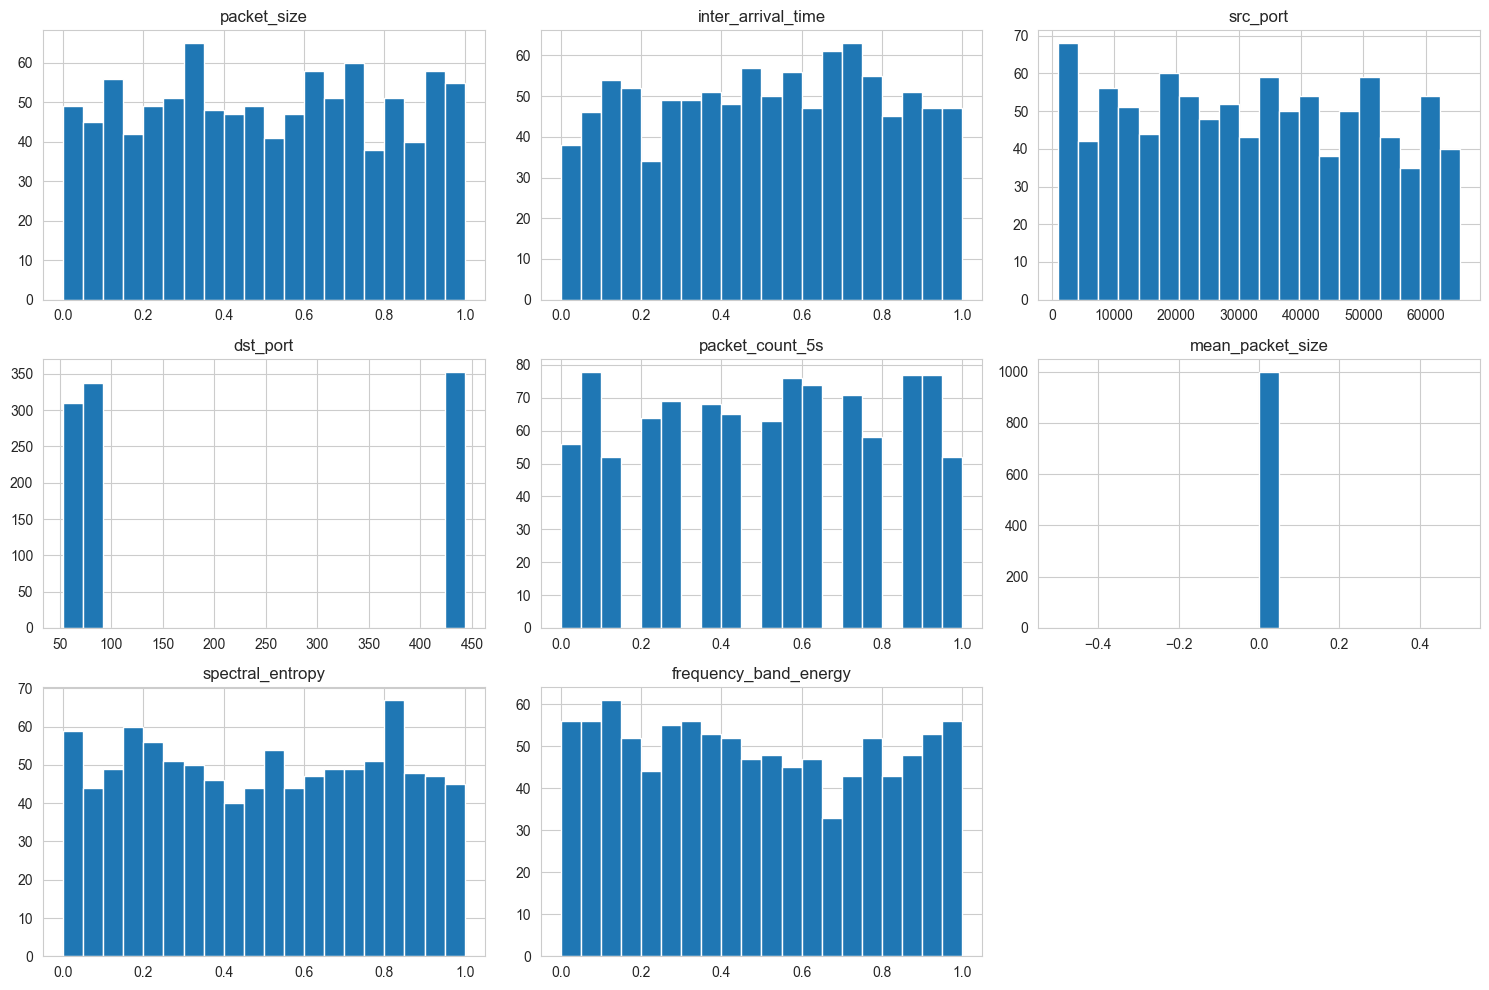

In [15]:

# Numerical Features Distribution


numerical_features = [
    'packet_size',
    'inter_arrival_time',
    'src_port',
    'dst_port',
    'packet_count_5s',
    'mean_packet_size',
    'spectral_entropy',
    'frequency_band_energy'
]

df[numerical_features].hist(
    figsize=(15,10),
    bins=20
)

plt.tight_layout()
plt.show()

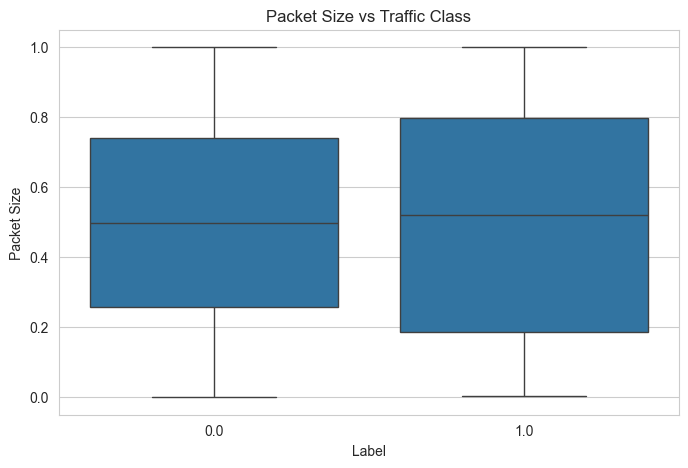

In [16]:

# Packet Size by Traffic Type


plt.figure(figsize=(8,5))

sns.boxplot(
    x='label',
    y='packet_size',
    data=df
)

plt.title("Packet Size vs Traffic Class")
plt.xlabel("Label")
plt.ylabel("Packet Size")

plt.show()

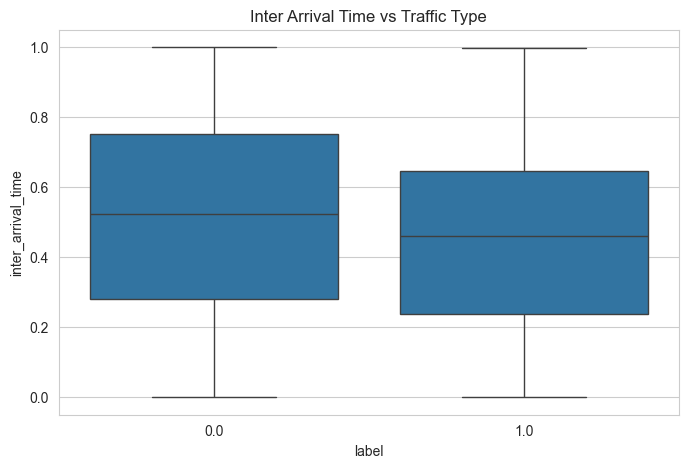

In [17]:

# Inter Arrival Time Analysis


plt.figure(figsize=(8,5))

sns.boxplot(
    x='label',
    y='inter_arrival_time',
    data=df
)

plt.title("Inter Arrival Time vs Traffic Type")

plt.show()

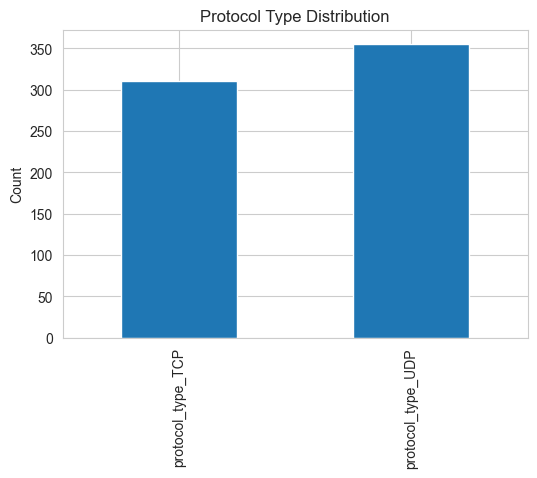

In [18]:

# Protocol Type Distribution


protocol_cols = [
    'protocol_type_TCP',
    'protocol_type_UDP'
]

protocol_counts = df[protocol_cols].sum()

plt.figure(figsize=(6,4))

protocol_counts.plot(kind='bar')

plt.title("Protocol Type Distribution")
plt.ylabel("Count")

plt.show()

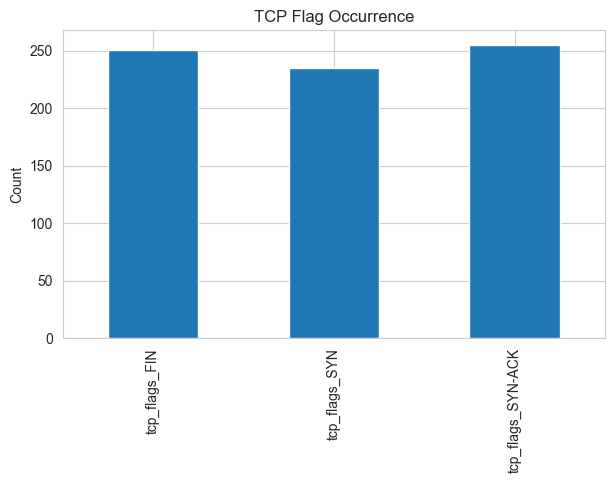

In [19]:

# TCP Flags Distribution

tcp_flags = [
    'tcp_flags_FIN',
    'tcp_flags_SYN',
    'tcp_flags_SYN-ACK'
]

flag_counts = df[tcp_flags].sum()

plt.figure(figsize=(7,4))

flag_counts.plot(kind='bar')

plt.title("TCP Flag Occurrence")
plt.ylabel("Count")

plt.show()

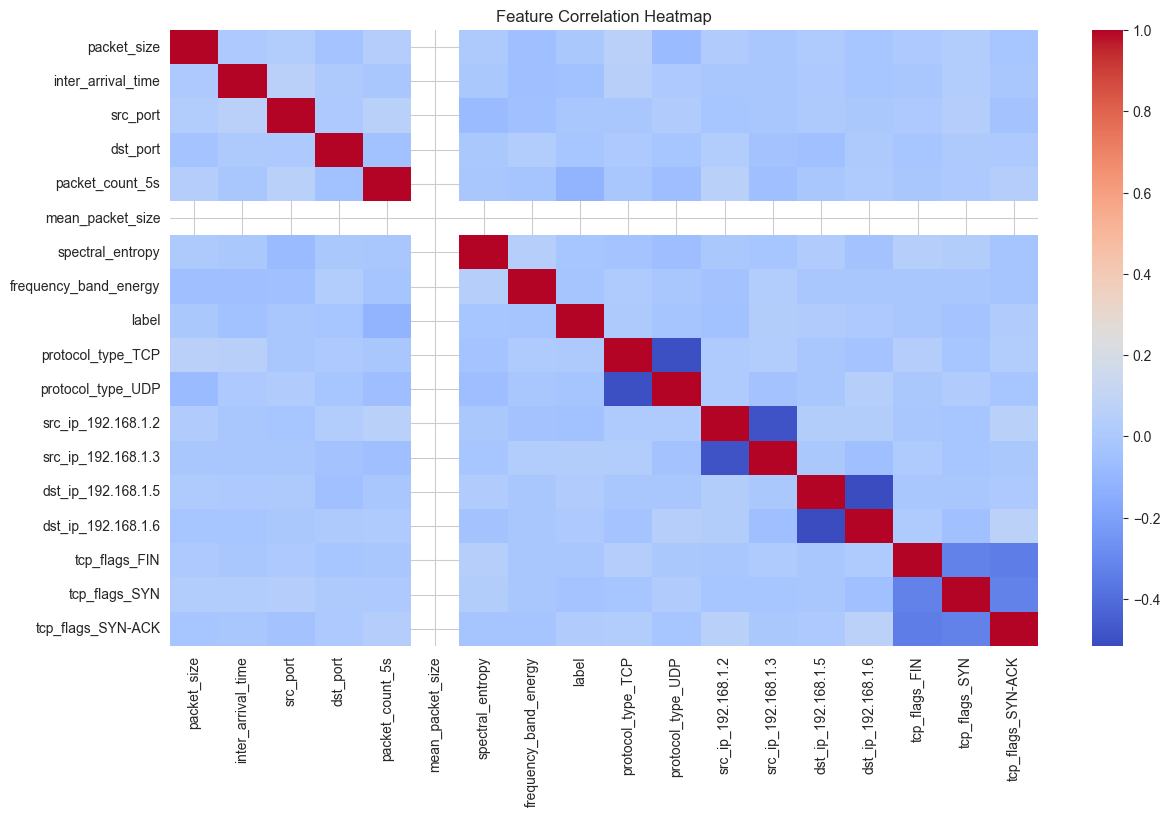

In [20]:

# Correlation Heatmap

plt.figure(figsize=(14,8))

corr_matrix = df.corr()

sns.heatmap(
    corr_matrix,
    annot=False,
    cmap='coolwarm'
)

plt.title("Feature Correlation Heatmap")

plt.show()

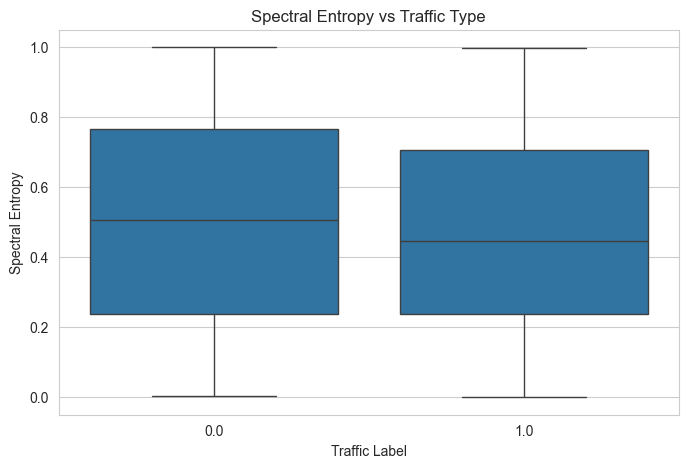

In [21]:

# Spectral Entropy vs Traffic Type


plt.figure(figsize=(8,5))

sns.boxplot(
    x='label',
    y='spectral_entropy',
    data=df
)

plt.title("Spectral Entropy vs Traffic Type")
plt.xlabel("Traffic Label")
plt.ylabel("Spectral Entropy")

plt.show()


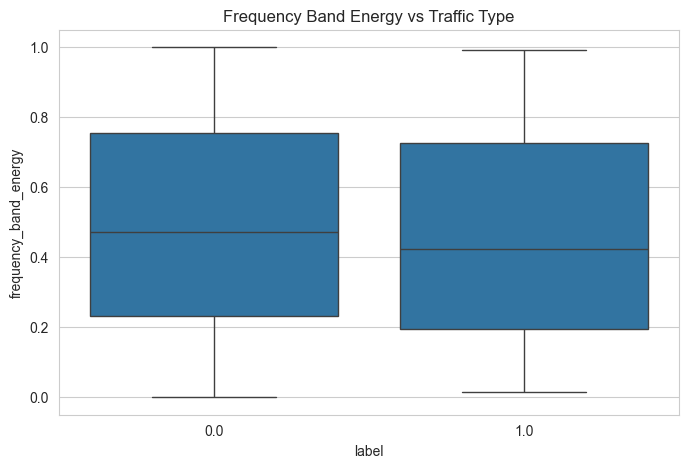

In [22]:

# Frequency Band Energy Analysis


plt.figure(figsize=(8,5))

sns.boxplot(
    x='label',
    y='frequency_band_energy',
    data=df
)

plt.title("Frequency Band Energy vs Traffic Type")

plt.show()

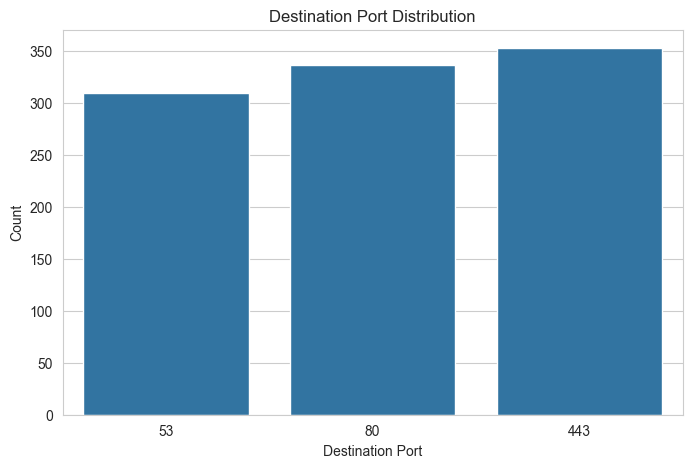

In [23]:

# Destination Port Distribution


plt.figure(figsize=(8,5))

sns.countplot(
    x='dst_port',
    data=df
)

plt.title("Destination Port Distribution")
plt.xlabel("Destination Port")
plt.ylabel("Count")

plt.show()

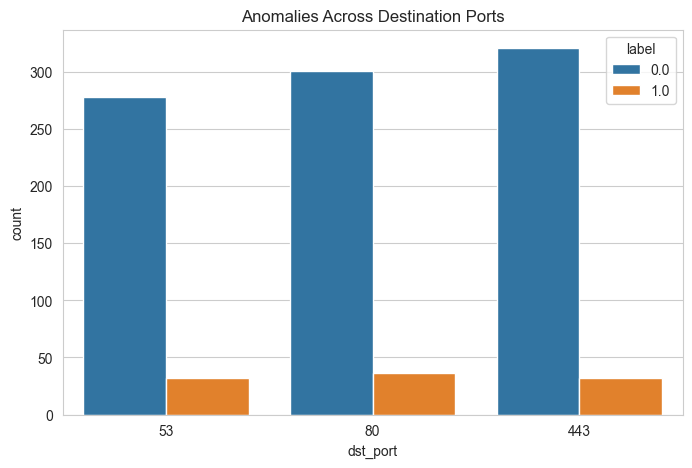

In [24]:

# Traffic Label by Destination Port


plt.figure(figsize=(8,5))

sns.countplot(
    x='dst_port',
    hue='label',
    data=df
)

plt.title("Anomalies Across Destination Ports")

plt.show()

In [25]:

# Detect Constant Features


low_variance_cols = []

for col in df.columns:
    
    if df[col].nunique() <= 1:
        low_variance_cols.append(col)

print("Low Variance Columns:")
print(low_variance_cols)

Low Variance Columns:
['mean_packet_size']


In [26]:

# Drop Constant Columns


df.drop(columns=low_variance_cols,
        inplace=True,
        errors='ignore')

print("Updated Shape :", df.shape)

Updated Shape : (1000, 17)


In [27]:

# Feature Engineering
# Traffic Rate


df['traffic_rate'] = (
    df['packet_count_5s'] /
    (df['inter_arrival_time'] + 0.0001)
)

df[['traffic_rate']].head()

,traffic_rate
0,1.381458
1,1.059789
2,0.588839
3,0.316711
4,0.803616


In [28]:

# Port Difference Feature


df['port_difference'] = abs(
    df['src_port'] -
    df['dst_port']
)

df[['port_difference']].head()

,port_difference
0,62126
1,58939
2,65404
3,51654
4,26862


In [29]:

# Entropy Energy Ratio


df['entropy_energy_ratio'] = (
    df['spectral_entropy']
    /
    (df['frequency_band_energy'] + 0.0001)
)

df[['entropy_energy_ratio']].head()

,entropy_energy_ratio
0,1.559030
1,0.148554
2,26.824409
3,0.900987
4,1.673296


In [30]:
import sys
print(sys.executable)

c:\Users\Keerthana\anaconda3\python.exe


In [31]:
!pip install xgboost

In [32]:
import xgboost
print("XGBoost Installed Successfully")

XGBoost Installed Successfully


In [33]:
# Models

from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import IsolationForest

# XGBoost
from xgboost import XGBClassifier

In [34]:

# Check Data Types


df.dtypes

packet_size              float64
inter_arrival_time       float64
src_port                   int64
dst_port                   int64
packet_count_5s          float64
spectral_entropy         float64
frequency_band_energy    float64
label                    float64
protocol_type_TCP           bool
protocol_type_UDP           bool
src_ip_192.168.1.2          bool
src_ip_192.168.1.3          bool
dst_ip_192.168.1.5          bool
dst_ip_192.168.1.6          bool
tcp_flags_FIN               bool
tcp_flags_SYN               bool
tcp_flags_SYN-ACK           bool
traffic_rate             float64
port_difference            int64
entropy_energy_ratio     float64
dtype: object

In [35]:
# Convert Boolean to Integer


bool_cols = df.select_dtypes(
    include=['bool']
).columns

for col in bool_cols:
    df[col] = df[col].astype(int)

df.head()

,packet_size,inter_arrival_time,src_port,dst_port,packet_count_5s,spectral_entropy,frequency_band_energy,label,protocol_type_TCP,protocol_type_UDP,src_ip_192.168.1.2,src_ip_192.168.1.3,dst_ip_192.168.1.5,dst_ip_192.168.1.6,tcp_flags_FIN,tcp_flags_SYN,tcp_flags_SYN-ACK,traffic_rate,port_difference,entropy_energy_ratio
0,0.405154,0.620362,62569,443,0.857143,0.834066,0.534891,0.0,0,1,1,0,0,0,0,0,0,1.381458,62126,1.559030
1,0.527559,0.741288,59382,443,0.785714,0.147196,0.990757,0.0,0,1,0,0,0,1,0,1,0,1.059789,58939,0.148554
2,0.226199,0.485116,65484,80,0.285714,0.855192,0.031781,0.0,0,1,0,0,1,0,0,0,0,0.588839,65404,26.824409
3,0.573372,0.450965,51707,53,0.142857,0.153220,0.169958,0.0,0,0,0,1,0,0,0,0,0,0.316711,51654,0.900987
4,0.651396,0.888740,26915,53,0.714286,0.923916,0.552053,0.0,1,0,0,1,0,0,0,1,0,0.803616,26862,1.673296


In [36]:

# Feature Selection


X = df.drop('label', axis=1)

y = df['label']

print("Feature Shape :", X.shape)
print("Target Shape :", y.shape)

Feature Shape : (1000, 19)
Target Shape : (1000,)


In [37]:
# Train Test Split


from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Shape :", X_train.shape)
print("Testing Shape :", X_test.shape)

Training Shape : (800, 19)
Testing Shape : (200, 19)


In [38]:
# Feature Scaling

from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Scaling Completed")

Scaling Completed


In [39]:

# Random Forest Model


rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    class_weight='balanced'
)

rf_model.fit(
    X_train_scaled,
    y_train
)

print("Random Forest Trained")

Random Forest Trained


In [40]:
# Random Forest Prediction


rf_pred = rf_model.predict(
    X_test_scaled
)


rf_prob = rf_model.predict_proba(
    X_test_scaled
)[:,1]

In [41]:
# XGBoost Model


xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(
    X_train_scaled,
    y_train
)

print("XGBoost Trained")

XGBoost Trained


In [42]:

# XGBoost Prediction


xgb_pred = xgb_model.predict(
    X_test_scaled
)

xgb_prob = xgb_model.predict_proba(
    X_test_scaled
)[:,1]

In [43]:

# Isolation Forest Model


iso_model = IsolationForest(
    n_estimators=200,
    contamination=0.05,
    random_state=42
)

iso_model.fit(X_train_scaled)

print("Isolation Forest Trained")

Isolation Forest Trained


In [44]:

# Isolation Forest Prediction


iso_pred = iso_model.predict(X_test_scaled)

# Convert prediction:
# -1 → anomaly (1)
# 1 → normal (0)

iso_pred = np.where(
    iso_pred == -1,
    1,
    0
)

print("Prediction Completed")

Prediction Completed


In [45]:
# Random Forest Evaluation

rf_accuracy = accuracy_score(
    y_test,
    rf_pred
)

rf_precision = precision_score(
    y_test,
    rf_pred
)

rf_recall = recall_score(
    y_test,
    rf_pred
)

rf_f1 = f1_score(
    y_test,
    rf_pred
)

rf_auc = roc_auc_score(
    y_test,
    rf_prob
)

print("Random Forest Performance")
print("Accuracy :", rf_accuracy)
print("Precision :", rf_precision)
print("Recall :", rf_recall)
print("F1 Score :", rf_f1)
print("ROC AUC :", rf_auc)

Random Forest Performance
Accuracy : 0.9
Precision : 0.0
Recall : 0.0
F1 Score : 0.0
ROC AUC : 0.5922222222222223


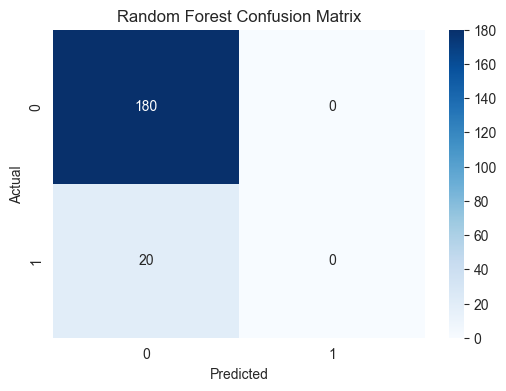

In [46]:
# Random Forest Confusion Matrix

cm = confusion_matrix(
    y_test,
    rf_pred
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [47]:
# Classification Report

print(
    classification_report(
        y_test,
        rf_pred
    )
)

              precision    recall  f1-score   support

         0.0       0.90      1.00      0.95       180
         1.0       0.00      0.00      0.00        20

    accuracy                           0.90       200
   macro avg       0.45      0.50      0.47       200
weighted avg       0.81      0.90      0.85       200



In [48]:
# XGBoost Evaluation

xgb_accuracy = accuracy_score(
    y_test,
    xgb_pred
)

xgb_precision = precision_score(
    y_test,
    xgb_pred
)

xgb_recall = recall_score(
    y_test,
    xgb_pred
)

xgb_f1 = f1_score(
    y_test,
    xgb_pred
)

xgb_auc = roc_auc_score(
    y_test,
    xgb_prob
)

print("XGBoost Performance")
print("Accuracy :", xgb_accuracy)
print("Precision :", xgb_precision)
print("Recall :", xgb_recall)
print("F1 Score :", xgb_f1)
print("ROC AUC :", xgb_auc)

XGBoost Performance
Accuracy : 0.895
Precision : 0.0
Recall : 0.0
F1 Score : 0.0
ROC AUC : 0.5916666666666667


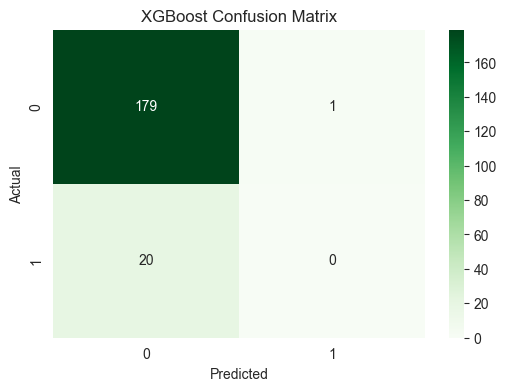

In [49]:
# XGBoost Confusion Matrix

cm = confusion_matrix(
    y_test,
    xgb_pred
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [50]:
# Isolation Forest Evaluation


iso_accuracy = accuracy_score(
    y_test,
    iso_pred
)

iso_precision = precision_score(
    y_test,
    iso_pred,
    zero_division=0
)

iso_recall = recall_score(
    y_test,
    iso_pred,
    zero_division=0
)

iso_f1 = f1_score(
    y_test,
    iso_pred,
    zero_division=0
)

print("Isolation Forest Performance")
print("Accuracy :", iso_accuracy)
print("Precision :", iso_precision)
print("Recall :", iso_recall)
print("F1 Score :", iso_f1)

Isolation Forest Performance
Accuracy : 0.825
Precision : 0.10526315789473684
Recall : 0.1
F1 Score : 0.10256410256410256


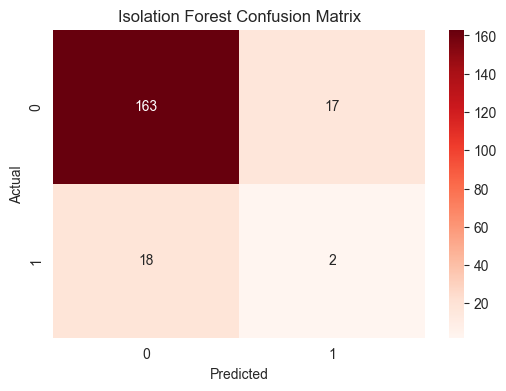

In [51]:
# Isolation Forest Confusion Matrix

cm = confusion_matrix(
    y_test,
    iso_pred
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Reds'
)

plt.title("Isolation Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [52]:
# Model Comparison Table

comparison_df = pd.DataFrame({

    'Model': [
        'Random Forest',
        'XGBoost',
        'Isolation Forest'
    ],

    'Accuracy': [
        rf_accuracy,
        xgb_accuracy,
        iso_accuracy
    ],

    'Precision': [
        rf_precision,
        xgb_precision,
        iso_precision
    ],

    'Recall': [
        rf_recall,
        xgb_recall,
        iso_recall
    ],

    'F1 Score': [
        rf_f1,
        xgb_f1,
        iso_f1
    ]
})

comparison_df.sort_values(
    by='F1 Score',
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score
2,Isolation Forest,0.825,0.105263,0.1,0.102564
0,Random Forest,0.900,0.000000,0.0,0.000000
1,XGBoost,0.895,0.000000,0.0,0.000000


In [53]:
# Feature Importance

feature_importance = pd.DataFrame({

    'Feature': X.columns,
    'Importance': rf_model.feature_importances_

})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
1,inter_arrival_time,0.123952
18,entropy_energy_ratio,0.102786
5,spectral_entropy,0.102746
0,packet_size,0.098895
16,traffic_rate,0.096957
6,frequency_band_energy,0.093803
17,port_difference,0.081741
2,src_port,0.080769
4,packet_count_5s,0.075924
3,dst_port,0.022733


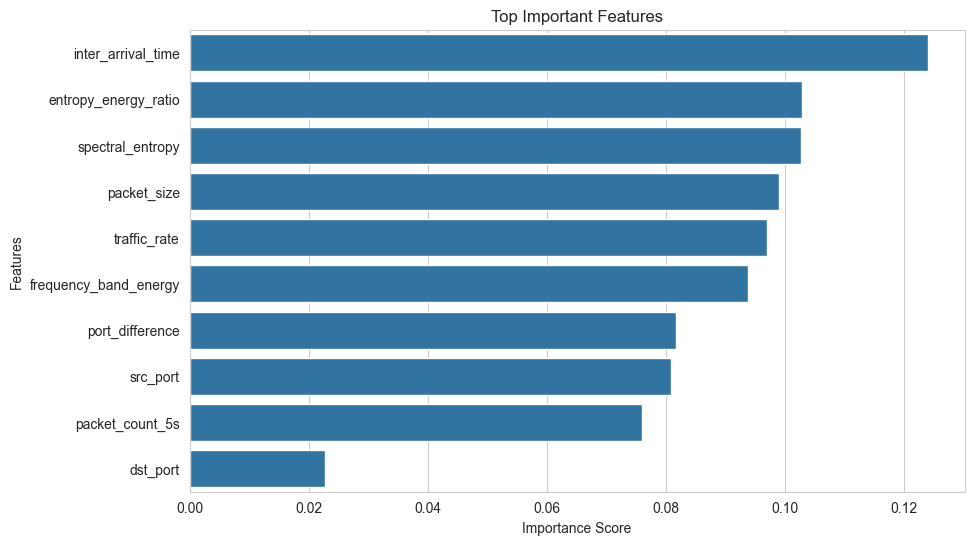

In [54]:
# Plot Feature Importance

top_features = feature_importance.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=top_features
)

plt.title("Top Important Features")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.show()

In [55]:
# Save Best Model

joblib.dump(
    rf_model,
    "network_anomaly_model.pkl"
)

print("Model Saved Successfully")

Model Saved Successfully


In [56]:
# Save Scaler

joblib.dump(
    scaler,
    "network_scaler.pkl"
)

print("Scaler Saved Successfully")

Scaler Saved Successfully


In [57]:
# Load Saved Model

loaded_model = joblib.load(
    "network_anomaly_model.pkl"
)

loaded_scaler = joblib.load(
    "network_scaler.pkl"
)

print("Model Loaded Successfully")

Model Loaded Successfully


In [58]:
# Sample Prediction

sample_input = X.iloc[[0]]

sample_scaled = loaded_scaler.transform(
    sample_input
)

prediction = loaded_model.predict(
    sample_scaled
)

print("Prediction :", prediction[0])

if prediction[0] == 0:
    print("Normal Traffic")
else:
    print("Anomalous Traffic Detected")

Prediction : 0.0
Normal Traffic


In [59]:
# Custom Prediction

custom_data = pd.DataFrame({

'packet_size':[0.45],
'inter_arrival_time':[0.20],
'src_port':[5000],
'dst_port':[443],
'packet_count_5s':[0.80],
'spectral_entropy':[0.75],
'frequency_band_energy':[0.60],
'protocol_type_TCP':[1],
'protocol_type_UDP':[0],
'src_ip_192.168.1.2':[1],
'src_ip_192.168.1.3':[0],
'dst_ip_192.168.1.5':[0],
'dst_ip_192.168.1.6':[1],
'tcp_flags_FIN':[0],
'tcp_flags_SYN':[1],
'tcp_flags_SYN-ACK':[0],

# Engineered Features
'traffic_rate':[
    0.80/(0.20+0.0001)
],

'port_difference':[
    abs(5000-443)
],

'entropy_energy_ratio':[
    0.75/(0.60+0.0001)
]

})

custom_scaled = loaded_scaler.transform(
    custom_data
)

prediction = loaded_model.predict(
    custom_scaled
)

print("Prediction :", prediction[0])

if prediction[0] == 0:
    print("Normal Network Traffic")
else:
    print("Anomaly Detected")

Prediction : 0.0
Normal Network Traffic
